In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

In [4]:
from electricusage import fetch_data, save_data, clean_and_resample_data

df = clean_and_resample_data(fetch_data())

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)
c:\Users\Lenovo\git\DatasetsAnalysis\src\electricusage.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_cleaned.resample('H').mean()


## Wyświetlanie podstawowych informacji na surowych danych

Ogólne informacje o danych:

In [7]:
import pandas as pd
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day_of_week,Is_Weekend
Datetime,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,1
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,1
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,1
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,1
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,1


In [9]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day_of_week,Is_Weekend
count,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34589.000000,34589.000000,34589.000000
mean,1.091728,0.123727,240.839393,4.628238,1.121631,1.298566,6.458882,11.501084,2.998959,0.285380
std,0.897619,0.066851,3.001093,3.757797,3.538046,4.192874,7.351219,6.922394,2.000072,0.451602
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.341925,0.078000,239.180667,1.513333,0.000000,0.000000,0.650000,6.000000,1.000000,0.000000
50%,0.802850,0.106917,240.977833,3.423333,0.000000,0.333333,1.650000,12.000000,3.000000,0.000000
75%,1.579342,0.149433,242.695000,6.606667,0.000000,0.650000,14.216667,18.000000,5.000000,1.000000
max,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,21.550000,23.000000,6.000000,1.000000


In [10]:
print(df.shape)

(34589, 10)


Okres zbierania danych:

In [11]:
print(f"Początek danych: {df.index.min()}")
print(f"Koniec danych: {df.index.max()}")

dni = (df.index.max() - df.index.min()).days
print(f"Liczba dni w zbiorze: {dni}")

Początek danych: 2006-12-16 17:00:00
Koniec danych: 2010-11-26 21:00:00
Liczba dni w zbiorze: 1441


Liczba pomiarów na każdy rok:

In [14]:
df.index.year.value_counts().sort_index()

Datetime
2006     367
2007    8760
2008    8784
2009    8760
2010    7918
Name: count, dtype: int64

Średnie zużycie wg miesięcy:

In [ ]:
df_energy = pd.DataFrame(index=monthly_comparison.index)
df_energy['Total_Energy_Wh'] = monthly_comparison['Global_active_power'] * 1000
df_energy['Sub3_Energy_Wh'] = monthly_comparison['Sub_metering_3'] * 60

display(df_energy)

,Total_Energy_Wh,Sub3_Energy_Wh
January,1462.345602,467.689447
February,1300.305399,455.126908
March,1231.274669,415.616476
April,1047.034744,400.537931
May,1029.571796,401.804408
June,909.430488,370.588435
July,700.415342,256.438431
August,573.417859,231.577578
September,975.752916,381.419047
October,1137.325800,395.126688


### Wizualizacja danych

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

Średnie zużycie według dni tygodnia

Średnie zużycie energii (kW) w podziale na dni tygodnia:
Monday       0.999630
Tuesday      1.069816
Wednesday    1.082855
Thursday     0.982008
Friday       1.043383
Saturday     1.248634
Sunday       1.219996
Name: Global_active_power, dtype: float64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16016\488696972.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_avg.index, y=day_avg.values, palette='coolwarm')


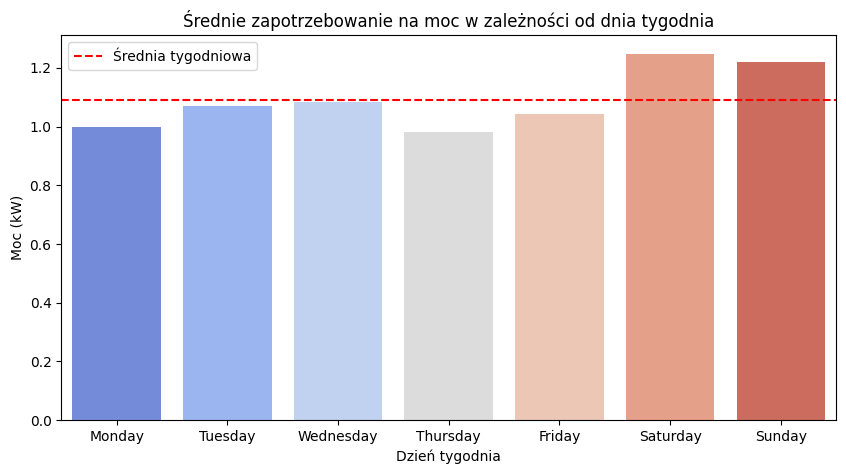

In [34]:
import calendar

day_avg = df.groupby('Day_of_week')['Global_active_power'].mean()
day_avg.index = [calendar.day_name[i] for i in day_avg.index]

print("Średnie zużycie energii (kW) w podziale na dni tygodnia:")
print(day_avg)

plt.figure(figsize=(10, 5))
sns.barplot(x=day_avg.index, y=day_avg.values, palette='coolwarm')
plt.title('Średnie zapotrzebowanie na moc w zależności od dnia tygodnia')
plt.ylabel('Moc (kW)')
plt.xlabel('Dzień tygodnia')

plt.axhline(df['Global_active_power'].mean(), color='red', linestyle='--', label='Średnia tygodniowa')
plt.legend()
plt.show()

Wyswietlanie śreniego zużycia według godziny i określenie godzin szczytu 

TOP 5 godzin o najwyższym zużyciu (średnia kW):
Hour
20    1.899073
21    1.876063
19    1.733428
7     1.502373
8     1.460940
Name: Global_active_power, dtype: float64


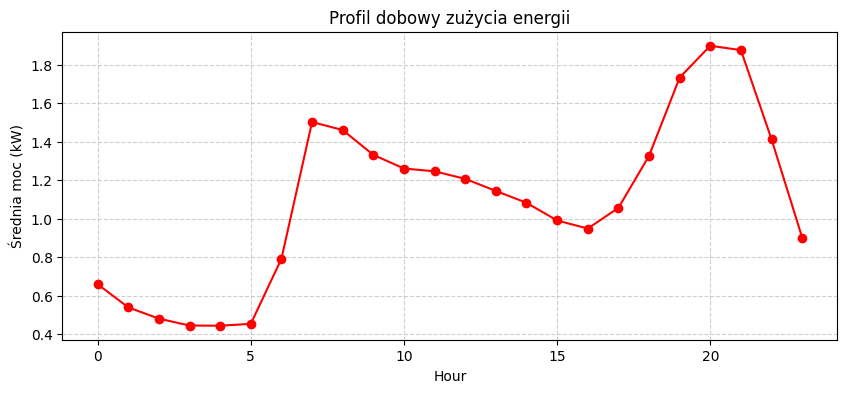

In [35]:
peak_hours = df.groupby('Hour')['Global_active_power'].mean().sort_values(ascending=False)

print("TOP 5 godzin o najwyższym zużyciu (średnia kW):")
print(peak_hours.head(5))

plt.figure(figsize=(10, 4))
df.groupby('Hour')['Global_active_power'].mean().plot(kind='line', marker='o', color='red')
plt.title('Profil dobowy zużycia energii')
plt.ylabel('Średnia moc (kW)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Porowanie weekend vs dzien roboczy

In [36]:
weekend_comparison = df.groupby('Is_Weekend')['Global_active_power'].agg(['mean', 'std', 'max'])
weekend_comparison.index = ['Dzień roboczy', 'Weekend']

print("Porównanie zużycia: Dni robocze vs Weekendy")
display(weekend_comparison)

Porównanie zużycia: Dni robocze vs Weekendy


,mean,std,max
Dzień roboczy,1.035586,0.835415,6.519633
Weekend,1.234285,1.025294,6.560533


Sprawdzenie zaleznosci calkowitego zuzycia od zuzycia boilera 

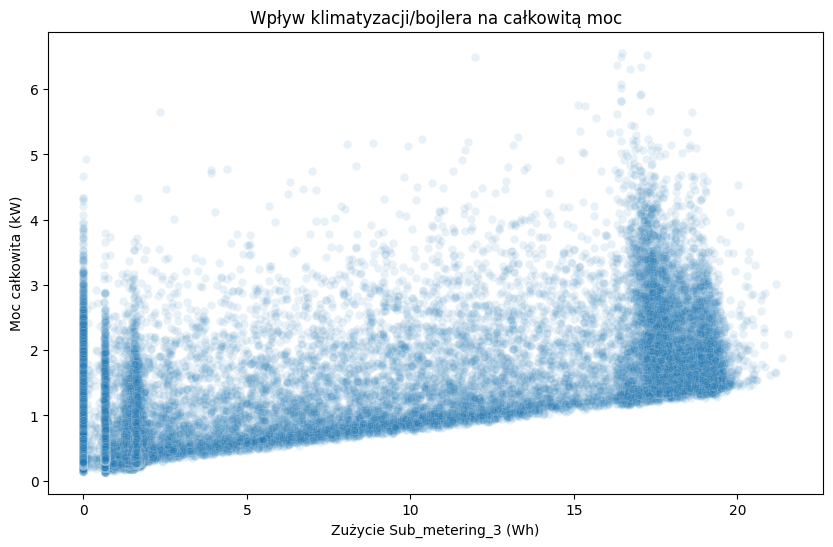

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sub_metering_3', y='Global_active_power', alpha=0.1)
plt.title('Wpływ klimatyzacji/bojlera na całkowitą moc')
plt.xlabel('Zużycie Sub_metering_3 (Wh)')
plt.ylabel('Moc całkowita (kW)')
plt.show()

Wyświetlenie macierzy korelacji

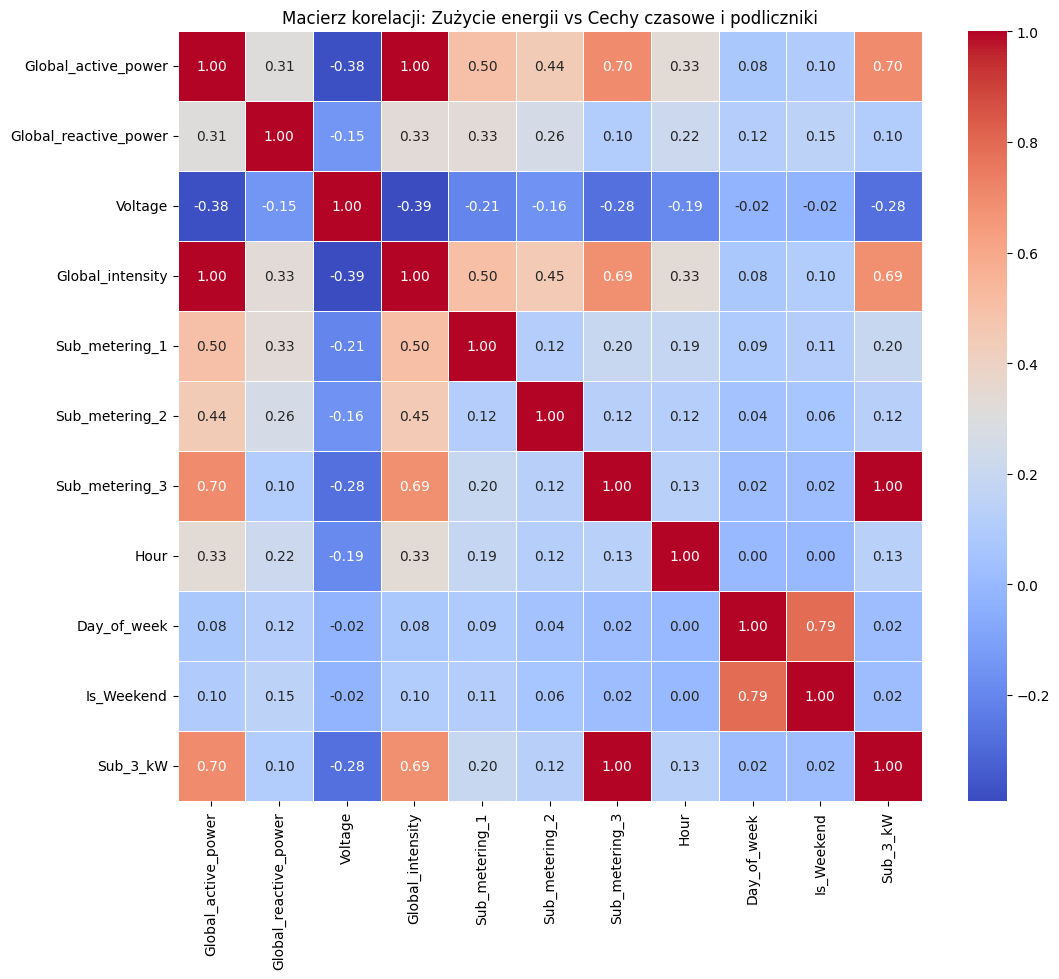

Korelacja z Global_active_power (zapotrzebowanie na energię):
Global_active_power      1.000000
Global_intensity         0.999423
Sub_metering_3           0.695540
Sub_3_kW                 0.695540
Sub_metering_1           0.496331
Sub_metering_2           0.440171
Hour                     0.331651
Global_reactive_power    0.312322
Is_Weekend               0.099667
Day_of_week              0.077487
Voltage                 -0.379450
Name: Global_active_power, dtype: float64


In [41]:
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Macierz korelacji: Zużycie energii vs Cechy czasowe i podliczniki')
plt.show()

print("Korelacja z Global_active_power (zapotrzebowanie na energię):")
print(corr_matrix['Global_active_power'].sort_values(ascending=False))